In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("weather_data(1) (1).csv")

In [5]:
df.head()

,Date,Temperature,Humidity,WindSpeed,Rainfall
0,2022-01-01,18.0,83.9,8.8,2.0
1,2022-01-02,17.7,82.0,7.4,1.1
2,2022-01-03,18.0,79.6,8.6,3.0
3,2022-01-04,17.3,83.8,8.8,1.8
4,2022-01-05,16.7,82.3,8.7,3.5


In [6]:
df.tail()

,Date,Temperature,Humidity,WindSpeed,Rainfall
1000,2024-04-21,30.7,71.2,5.7,0.0
1001,2024-08-14,32.5,NaN,11.0,18.3
1002,2023-06-29,35.4,67.8,3.6,37.9
1003,2022-06-23,32.1,64.1,10.6,25.2
1004,2024-01-30,20.9,83.8,9.4,0.0


In [7]:
df.shape

(1005, 5)

In [8]:
df.columns

Index(['Date', 'Temperature', 'Humidity', 'WindSpeed', 'Rainfall'], dtype='object')

In [9]:
df.dtypes

Date            object
Temperature    float64
Humidity       float64
WindSpeed      float64
Rainfall       float64
dtype: object

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
df

,Date,Temperature,Humidity,WindSpeed,Rainfall
0,2022-01-01,18.0,83.9,8.8,2.0
1,2022-01-02,17.7,82.0,7.4,1.1
2,2022-01-03,18.0,79.6,8.6,3.0
3,2022-01-04,17.3,83.8,8.8,1.8
4,2022-01-05,16.7,82.3,8.7,3.5
...,...,...,...,...,...
1000,2024-04-21,30.7,71.2,5.7,0.0
1001,2024-08-14,32.5,NaN,11.0,18.3
1002,2023-06-29,35.4,67.8,3.6,37.9
1003,2022-06-23,32.1,64.1,10.6,25.2


In [14]:
df.dtypes

Date           datetime64[ns]
Temperature           float64
Humidity              float64
WindSpeed             float64
Rainfall              float64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1005 non-null   object 
 1   Temperature  997 non-null    float64
 2   Humidity     996 non-null    float64
 3   WindSpeed    997 non-null    float64
 4   Rainfall     997 non-null    float64
dtypes: float64(4), object(1)
memory usage: 39.4+ KB


In [11]:
df.describe()

,Temperature,Humidity,WindSpeed,Rainfall
count,997.000000,996.000000,997.000000,997.000000
mean,26.663892,76.942771,10.159679,8.530692
std,6.622622,8.410687,3.155014,10.970796
min,4.000000,52.100000,2.000000,0.000000
25%,20.700000,71.400000,8.100000,1.000000
50%,27.600000,77.200000,10.200000,3.100000
75%,32.400000,82.600000,12.200000,14.300000
max,52.000000,105.000000,45.000000,120.000000


In [15]:
df.isnull().sum()

Date           0
Temperature    8
Humidity       9
WindSpeed      8
Rainfall       8
dtype: int64

In [16]:
df.duplicated().sum()

5

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

0

In [19]:
df.isnull().sum()

Date           0
Temperature    8
Humidity       8
WindSpeed      8
Rainfall       8
dtype: int64

In [20]:
df["Temperature"].fillna(df["Temperature"].median(), inplace=True)
df["Humidity"].fillna(df["Humidity"].median(), inplace=True)
df["WindSpeed"].fillna(df["WindSpeed"].median(), inplace=True)
df["Rainfall"].fillna(df["Rainfall"].median(), inplace=True)

In [21]:
df.isnull().sum()

Date           0
Temperature    0
Humidity       0
WindSpeed      0
Rainfall       0
dtype: int64

In [26]:
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

df.head()

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year
0,2022-01-01,18.0,83.9,8.8,2.0,January,2022
1,2022-01-02,17.7,82.0,7.4,1.1,January,2022
2,2022-01-03,18.0,79.6,8.6,3.0,January,2022
3,2022-01-04,17.3,83.8,8.8,1.8,January,2022
4,2022-01-05,16.7,82.3,8.7,3.5,January,2022


In [69]:
def get_season(month):
    if month in [10,11,12,1]:
        return "Winter"
    elif month in [2,3, 4, 5]:
        return "Summer"
    else:
        return "Monsoon"

df["Season"] = df["Date"].dt.month.apply(get_season)

df.head()

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season,Month_Year,Rolling_Avg
0,2022-01-01,18.0,83.9,8.8,2.0,January,2022,Winter,2022-01,NaN
1,2022-01-02,17.7,82.0,7.4,1.1,January,2022,Winter,2022-01,NaN
2,2022-01-03,18.0,79.6,8.6,3.0,January,2022,Winter,2022-01,NaN
3,2022-01-04,17.3,83.8,8.8,1.8,January,2022,Winter,2022-01,NaN
4,2022-01-05,16.7,82.3,8.7,3.5,January,2022,Winter,2022-01,NaN


In [28]:
monthly_summary = df.groupby("Month")["Temperature"].agg(["mean", "median", "std"])

monthly_summary

,mean,median,std
Month,,,
April,29.790000,29.70,2.212683
August,31.073656,31.00,3.187455
December,17.226613,17.00,2.489679
February,21.096471,20.90,2.501164
January,18.317742,18.20,2.245704
July,33.887097,33.90,2.053588
June,34.551111,35.15,3.771634
March,25.508602,25.50,2.469186
May,33.131183,33.30,2.120076


In [29]:
season_summary = df.groupby("Season")["Temperature"].agg(["mean", "median", "std"])

season_summary

,mean,median,std
Season,,,
Post-Monsoon,31.649586,32.35,4.195647
Summer,27.500831,28.10,5.058251
Winter,19.017148,18.70,3.001603


In [30]:
#hottest day
df[df["Temperature"] == df["Temperature"].max()]

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season
601,2023-08-25,52.0,74.2,6.6,27.6,August,2023,Post-Monsoon


In [31]:
#coolest day
df[df["Temperature"] == df["Temperature"].min()]

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season
521,2023-06-06,4.0,67.5,15.0,11.9,June,2023,Post-Monsoon


In [32]:
#Windiest Day
df[df["WindSpeed"] == df["WindSpeed"].max()]

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season
310,2022-11-07,21.6,63.8,45.0,3.1,November,2022,Winter


In [33]:
#Wettest Day
df[df["Rainfall"] == df["Rainfall"].max()]

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season
407,2023-02-12,22.7,87.2,6.8,120.0,February,2023,Summer


In [34]:
correlation = df[["Temperature", "Humidity", "WindSpeed", "Rainfall"]].corr()

correlation

,Temperature,Humidity,WindSpeed,Rainfall
Temperature,1.000000,-0.504333,-0.029569,0.419432
Humidity,-0.504333,1.000000,0.014431,-0.227149
WindSpeed,-0.029569,0.014431,1.000000,-0.027499
Rainfall,0.419432,-0.227149,-0.027499,1.000000


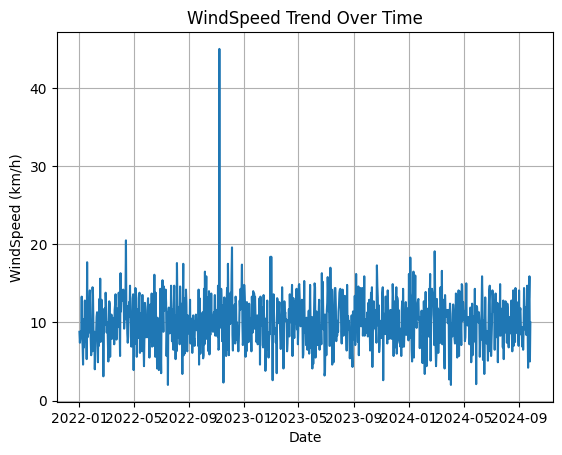

In [50]:
plt.plot(df["Date"], df["WindSpeed"])

plt.title("WindSpeed Trend Over Time")
plt.xlabel("Date")
plt.ylabel("WindSpeed (km/h)")
plt.grid(True)

plt.savefig(r"E:\PowerBI Desktop\Weather Data Analysis\plots\wind_trend.png", dpi=300)

plt.show()

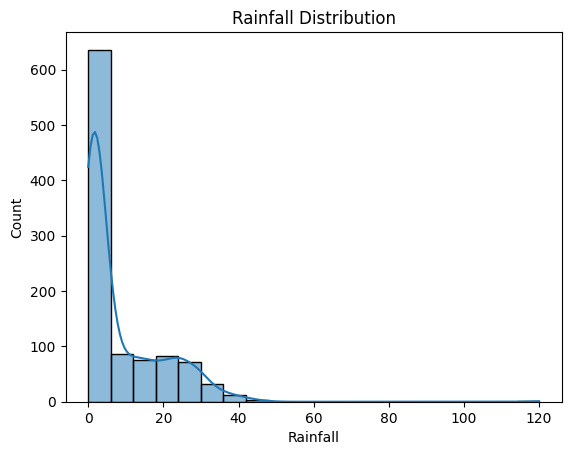

In [64]:
sns.histplot(df["Rainfall"], bins=20, kde=True)

plt.title("Rainfall Distribution")

plt.savefig(r"E:\PowerBI Desktop\Weather Data Analysis\plots\Rainfall_histogram.png", dpi=300)
plt.show()

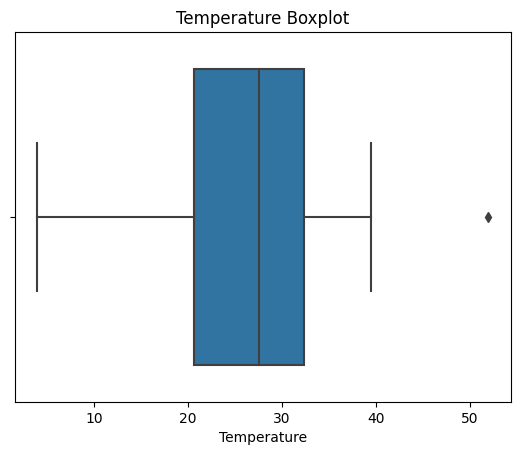

In [63]:
sns.boxplot(x=df["Temperature"])

plt.title("Temperature Boxplot")

plt.savefig(r"E:\PowerBI Desktop\Weather Data Analysis\plots\Temp_boxplot.png", dpi=300)
plt.show()

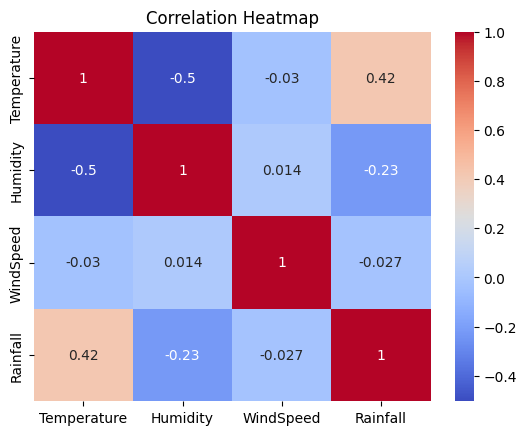

In [53]:
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig(r"E:\PowerBI Desktop\Weather Data Analysis\plots\correlation_heatmap.png", dpi=300)
plt.show()

In [54]:
df["Month_Year"] = df["Date"].dt.strftime("%Y-%m")
df.head()

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season,Month_Year
0,2022-01-01,18.0,83.9,8.8,2.0,January,2022,Winter,2022-01
1,2022-01-02,17.7,82.0,7.4,1.1,January,2022,Winter,2022-01
2,2022-01-03,18.0,79.6,8.6,3.0,January,2022,Winter,2022-01
3,2022-01-04,17.3,83.8,8.8,1.8,January,2022,Winter,2022-01
4,2022-01-05,16.7,82.3,8.7,3.5,January,2022,Winter,2022-01


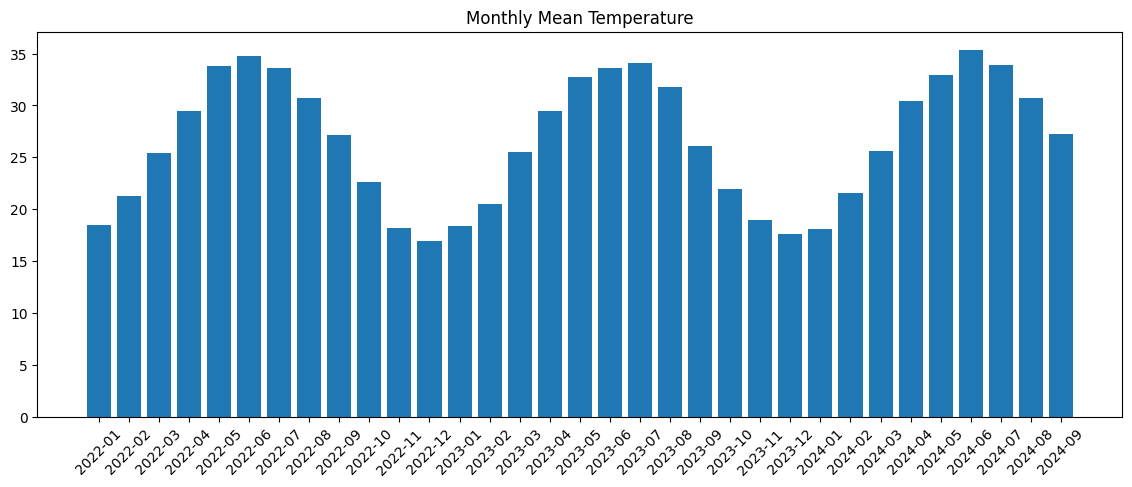

In [57]:
monthly_mean = df.groupby("Month_Year")["Temperature"].mean().reset_index()

plt.figure(figsize=(14,5))

plt.bar(monthly_mean["Month_Year"], monthly_mean["Temperature"])

plt.title("Monthly Mean Temperature")
plt.xticks(rotation=45)

plt.savefig(r"E:\PowerBI Desktop\Weather Data Analysis\plots\monthly_mean_temperature.png", dpi=300)
plt.show()

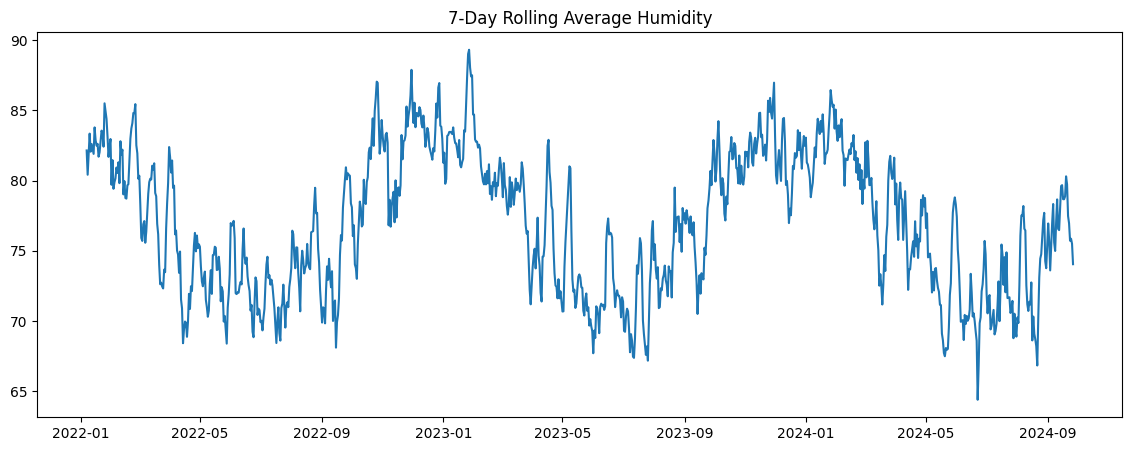

In [70]:
df["Rolling_Avg"] = df["Humidity"].rolling(7).mean()

plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["Rolling_Avg"])

plt.title("7-Day Rolling Average Humidity")

plt.savefig(r"E:\PowerBI Desktop\Weather Data Analysis\plots\rolling_average.png", dpi=300)
plt.show()

# Business Insights

In [65]:
# The monthly average temperature follows a clear seasonal pattern, with warmer months showing higher average temperatures.

# Rainfall is concentrated during the monsoon months, indicating seasonal precipitation patterns.

# The correlation heatmap shows a negative relationship between temperature and humidity.

# Most weather observations fall within the normal range, with only a few outliers detected during data cleaning.

# The cleaned dataset is suitable for visualization and future predictive analysis.

# Recommendations

In [66]:
# Plan outdoor activities during low rainfall months.
# Improve drainage systems before the monsoon season.
# Use the cleaned dataset for future weather forecasting.
# Continue monitoring temperature and rainfall trends for better planning.

In [71]:
df.to_csv(r"E:\PowerBI Desktop\Weather Data Analysis\data\Weather Data Analysis.csv", index=False)

In [72]:
df

,Date,Temperature,Humidity,WindSpeed,Rainfall,Month,Year,Season,Month_Year,Rolling_Avg
0,2022-01-01,18.0,83.9,8.8,2.0,January,2022,Winter,2022-01,NaN
1,2022-01-02,17.7,82.0,7.4,1.1,January,2022,Winter,2022-01,NaN
2,2022-01-03,18.0,79.6,8.6,3.0,January,2022,Winter,2022-01,NaN
3,2022-01-04,17.3,83.8,8.8,1.8,January,2022,Winter,2022-01,NaN
4,2022-01-05,16.7,82.3,8.7,3.5,January,2022,Winter,2022-01,NaN
...,...,...,...,...,...,...,...,...,...,...
995,2024-09-22,27.8,71.0,12.9,16.2,September,2024,Monsoon,2024-09,76.957143
996,2024-09-23,26.5,71.5,13.1,16.3,September,2024,Monsoon,2024-09,75.714286
997,2024-09-24,25.8,75.6,15.9,20.0,September,2024,Monsoon,2024-09,75.857143
998,2024-09-25,23.6,67.2,5.0,19.3,September,2024,Monsoon,2024-09,75.500000
